<a href="https://colab.research.google.com/github/Mohana12-Aiml/Telco_customer_churn/blob/main/telco_customer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42

In [ ]:
import pandas as pd
df=pd.read_excel("Telco_Customer_Churn.xlsx")
print(df)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     1803-URLLW  Female              0      No         No      13   
1     1773-SFCNZ    Male              1     Yes        Yes       3   
2     7621-TSUND    Male              0      No         No      10   
3     8556-LNJEY    Male              0     Yes         No      61   
4     8033-QKVOL  Female              1     Yes         No      28   
...          ...     ...            ...     ...        ...     ...   
1995  7107-JOBKJ    Male              1      No         No       0   
1996  5811-YYMQC  Female              0     Yes         No      69   
1997  5339-RRZMX  Female              0      No        Yes      57   
1998  9807-OCJTP  Female              1      No         No       7   
1999  9425-VBWJV  Female              0      No         No      36   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
0             Yes               Yes     Fiber optic                   No  ... 

In [ ]:
# 2. Load data
DATA_PATH = "Telco_Customer_Churn.xlsx"   # change to .csv + pd.read_csv if you exported CSV

df = pd.read_excel(DATA_PATH, sheet_name="Customer Data")
print(df.shape)
df.head()

(2000, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1803-URLLW,Female,0,No,No,13,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,No,Month-to-month,No,Bank transfer (automatic),92.59,1196.14,Yes
1,1773-SFCNZ,Male,1,Yes,Yes,3,Yes,No,Fiber optic,Yes,Yes,No,No,No,Yes,One year,No,Credit card (automatic),95.31,294.51,No
2,7621-TSUND,Male,0,No,No,10,Yes,No,Fiber optic,Yes,Yes,No,No,Yes,No,One year,No,Mailed check,92.04,908.48,No
3,8556-LNJEY,Male,0,Yes,No,61,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,26.35,1597.74,No
4,8033-QKVOL,Female,1,Yes,No,28,Yes,No,Fiber optic,Yes,No,No,No,No,No,Two year,Yes,Credit card (automatic),84.47,2386.28,Yes


In [ ]:
# 3. Basic cleaning
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"])  # new customers, tenure=0

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])
print()
print("Churn rate: {:.1%}".format(df["Churn"].mean()))

Missing values per column:
Series([], dtype: int64)

Churn rate: 33.9%


/tmp/ipykernel_740/125946138.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(["No", "Yes"])


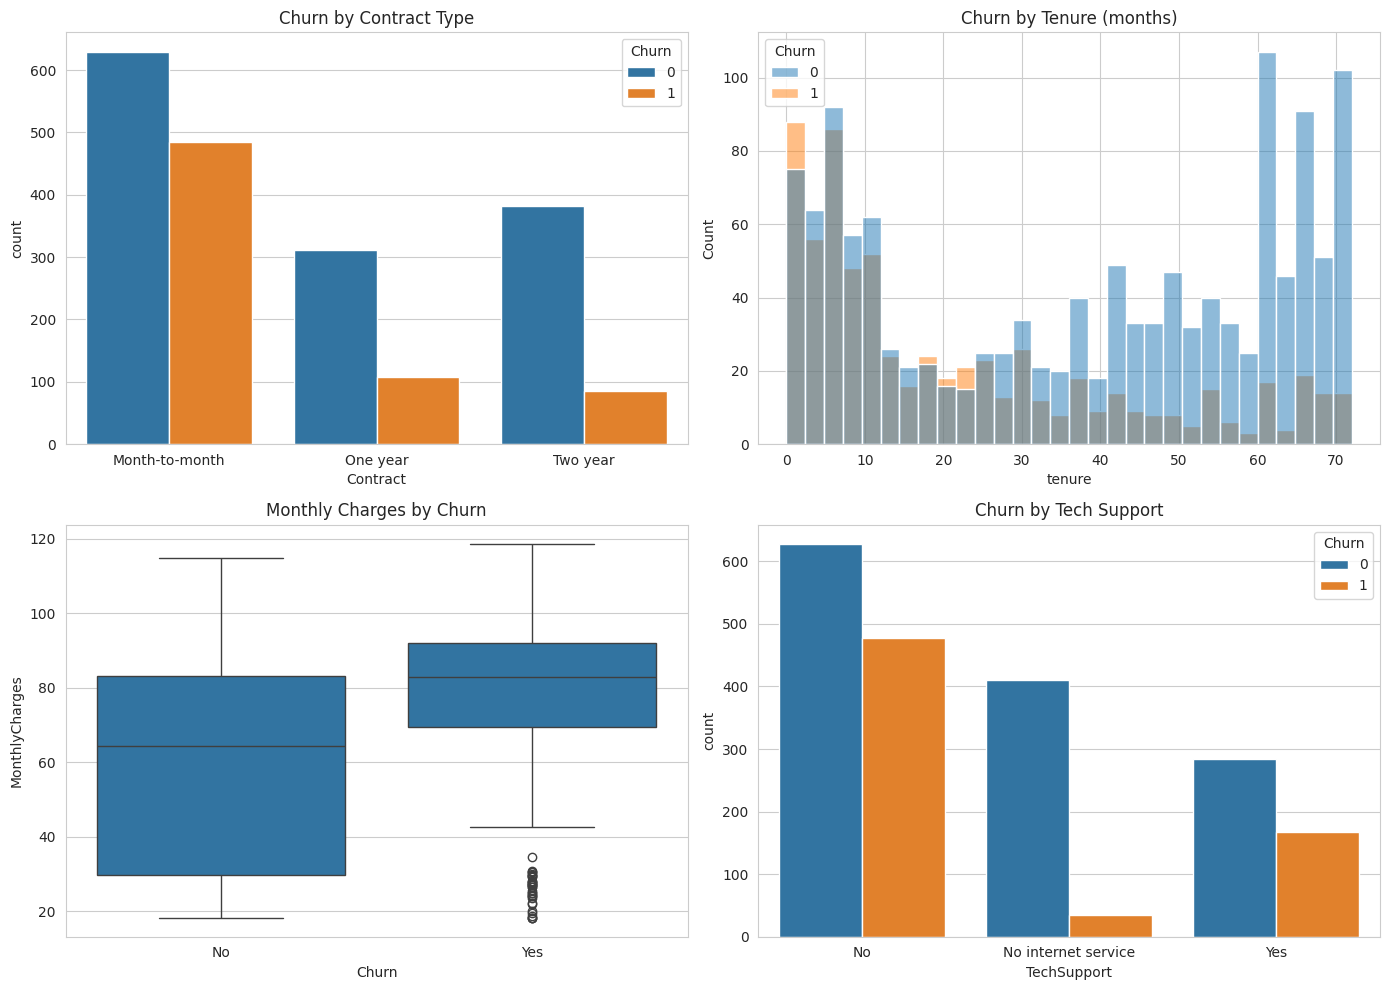

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[0, 0])
axes[0, 0].set_title("Churn by Contract Type")

sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=False, ax=axes[0, 1])
axes[0, 1].set_title("Churn by Tenure (months)")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1, 0])
axes[1, 0].set_title("Monthly Charges by Churn")
axes[1, 0].set_xticklabels(["No", "Yes"])

sns.countplot(data=df, x="TechSupport", hue="Churn", ax=axes[1, 1])
axes[1, 1].set_title("Churn by Tech Support")

plt.tight_layout()
plt.show()

In [ ]:
# Churn rate by contract type — quick sanity check of the business story
df.groupby("Contract")["Churn"].mean().sort_values(ascending=False).round(3)

,Churn
Contract,
Month-to-month,0.435
One year,0.258
Two year,0.182


In [ ]:
feature_df = df.drop(columns=["customerID"]).copy()

categorical_cols = feature_df.select_dtypes(include="object").columns.tolist()
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    feature_df[col] = le.fit_transform(feature_df[col])
    encoders[col] = le

X = feature_df.drop(columns=["Churn"])
y = feature_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape

((1500, 19), (500, 19))

In [ ]:
param_grid = {
    "max_depth": [3, 4, 5, 6],
    "min_samples_leaf": [20, 30, 50],
    "criterion": ["gini", "entropy"],
}

base_tree = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")
grid = GridSearchCV(base_tree, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
tree_clf = grid.best_estimator_

Best params: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 50}


In [ ]:
# 7. Evaluate
y_pred = tree_clf.predict(X_test)
y_proba = tree_clf.predict_proba(X_test)[:, 1]

print("Accuracy: {:.3f}".format(accuracy_score(y_test, y_pred)))
print("Precision: {:.3f}".format(precision_score(y_test, y_pred)))
print("Recall: {:.3f}".format(recall_score(y_test, y_pred)))
print("F1: {:.3f}".format(f1_score(y_test, y_pred)))
print("ROC AUC: {:.3f}".format(roc_auc_score(y_test, y_proba)))
print()
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

Accuracy: 0.744
Precision: 0.602
Recall: 0.716
F1: 0.654
ROC AUC: 0.816

              precision    recall  f1-score   support

    No Churn       0.84      0.76      0.80       331
       Churn       0.60      0.72      0.65       169

    accuracy                           0.74       500
   macro avg       0.72      0.74      0.73       500
weighted avg       0.76      0.74      0.75       500



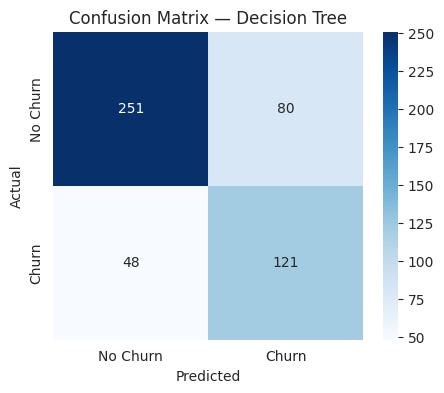

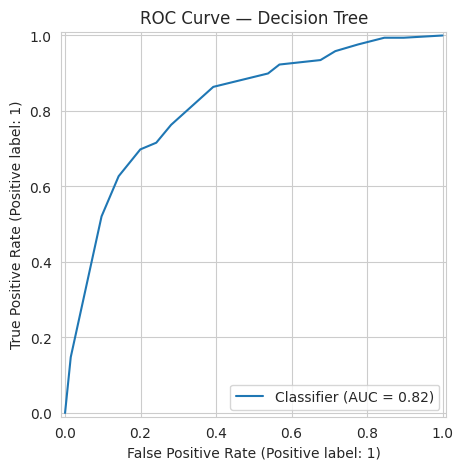

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix — Decision Tree")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve — Decision Tree")
plt.show()

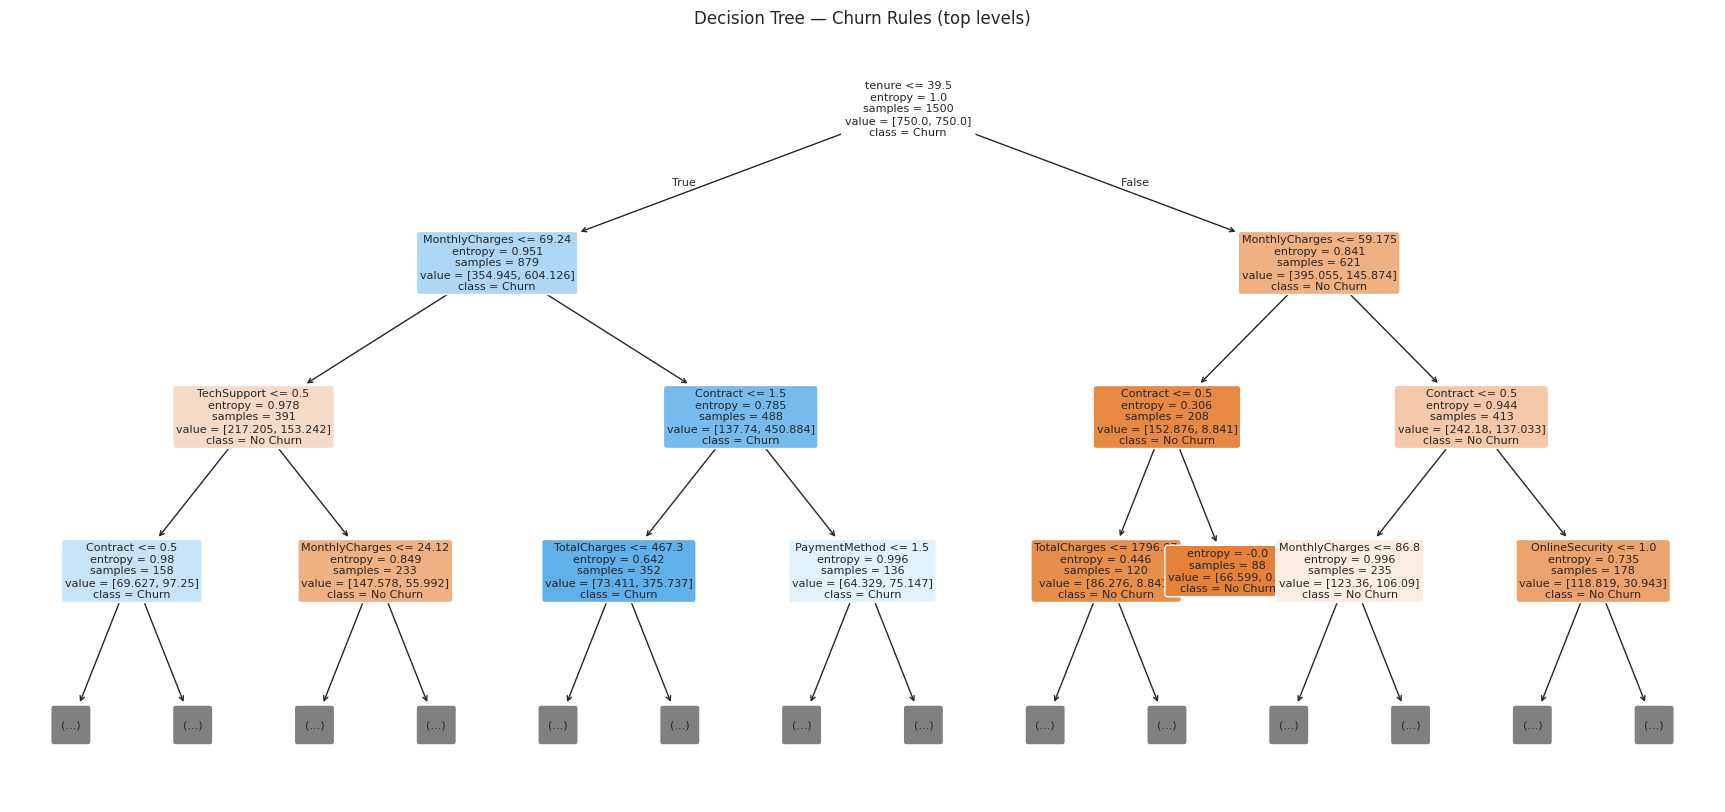

In [ ]:
plt.figure(figsize=(22, 10))
plot_tree(
    tree_clf,
    feature_names=X.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,   # visual depth cap for readability; the fitted tree may be deeper
)
plt.title("Decision Tree — Churn Rules (top levels)")
plt.show()

In [ ]:
rules_text = export_text(tree_clf, feature_names=list(X.columns))
print(rules_text)

|--- tenure <= 39.50
|   |--- MonthlyCharges <= 69.24
|   |   |--- TechSupport <= 0.50
|   |   |   |--- Contract <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Contract >  0.50
|   |   |   |   |--- class: 0
|   |   |--- TechSupport >  0.50
|   |   |   |--- MonthlyCharges <= 24.12
|   |   |   |   |--- class: 0
|   |   |   |--- MonthlyCharges >  24.12
|   |   |   |   |--- class: 0
|   |--- MonthlyCharges >  69.24
|   |   |--- Contract <= 1.50
|   |   |   |--- TotalCharges <= 467.30
|   |   |   |   |--- class: 1
|   |   |   |--- TotalCharges >  467.30
|   |   |   |   |--- class: 1
|   |   |--- Contract >  1.50
|   |   |   |--- PaymentMethod <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- PaymentMethod >  1.50
|   |   |   |   |--- class: 0
|--- tenure >  39.50
|   |--- MonthlyCharges <= 59.18
|   |   |--- Contract <= 0.50
|   |   |   |--- TotalCharges <= 1796.07
|   |   |   |   |--- class: 0
|   |   |   |--- TotalCharges >  1796.07
|   |   |   |   |--- class: 0
|   |   |--- 

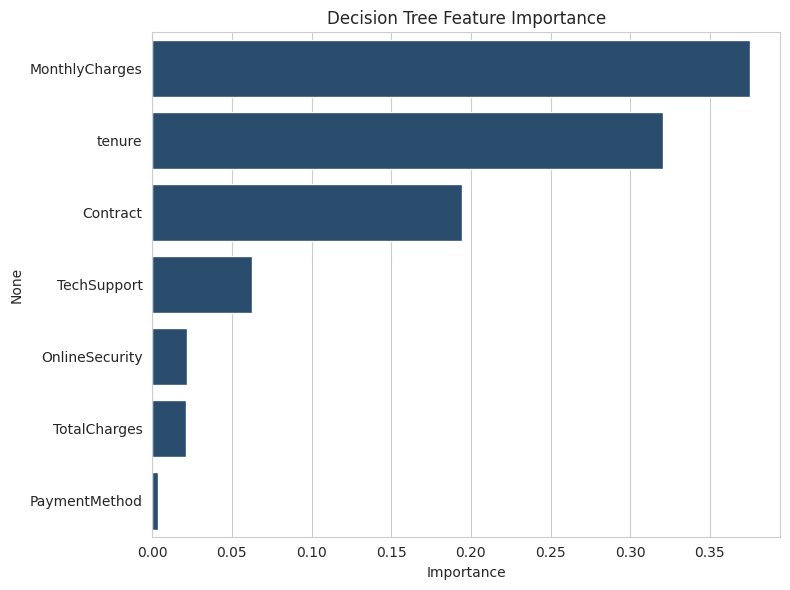

,0
MonthlyCharges,0.375279
tenure,0.320831
Contract,0.194505
TechSupport,0.062898
OnlineSecurity,0.021729
TotalCharges,0.021407
PaymentMethod,0.003351


In [ ]:
# Feature importance — which factors matter most for churn
importances = pd.Series(tree_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances = importances[importances > 0]

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color="#1F4E78")
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

In [ ]:
cluster_features = [
    "tenure", "MonthlyCharges", "TotalCharges",
    "InternetService", "Contract", "PaymentMethod",
    "OnlineSecurity", "TechSupport", "StreamingTV", "StreamingMovies",
    "MultipleLines", "PaperlessBilling",
]

X_cluster = feature_df[cluster_features].copy()
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

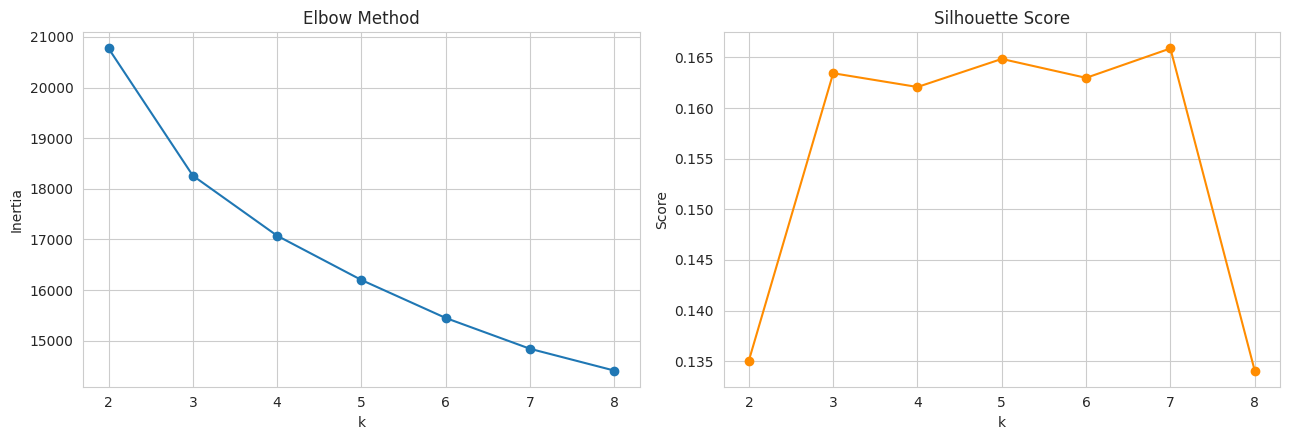

In [ ]:
# Choose k via elbow + silhouette score
inertias, sil_scores = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

In [ ]:
# Pick k (adjust based on the chart above — 4 is a reasonable default for behavioral profiles)
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,611
1,530
2,445
3,414


In [ ]:
profile = df.groupby("Cluster").agg(
    customers=("customerID", "count"),
    churn_rate=("Churn", lambda s: (s == 1).mean() if s.dtype != object else (s == "Yes").mean()),
    avg_tenure=("tenure", "mean"),
    avg_monthly_charges=("MonthlyCharges", "mean"),
    pct_month_to_month=("Contract", lambda s: (s == "Month-to-month").mean()),
    pct_fiber=("InternetService", lambda s: (s == "Fiber optic").mean()),
    pct_no_tech_support=("TechSupport", lambda s: (s == "No").mean()),
).round(2)

profile

,customers,churn_rate,avg_tenure,avg_monthly_charges,pct_month_to_month,pct_fiber,pct_no_tech_support
Cluster,,,,,,,
0,611,0.22,58.91,78.09,0.57,0.57,0.68
1,530,0.52,14.18,74.46,0.55,0.56,0.75
2,445,0.08,33.18,26.04,0.57,0.00,0.00
3,414,0.57,16.44,84.19,0.54,0.60,0.70


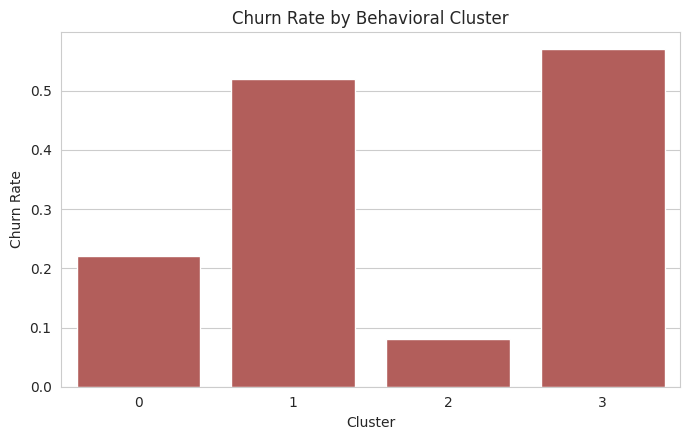

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=profile.index, y=profile["churn_rate"], color="#C0504D", ax=ax)
ax.set_title("Churn Rate by Behavioral Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Churn Rate")
plt.tight_layout()
plt.show()

In [ ]:
# Save enriched dataset (with cluster labels) for downstream reporting / dashboards
df.to_csv("telco_churn_with_clusters.csv", index=False)
print("Saved telco_churn_with_clusters.csv")
df.head()

Saved telco_churn_with_clusters.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Cluster
0,1803-URLLW,Female,0,No,No,13,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,No,Month-to-month,No,Bank transfer (automatic),92.59,1196.14,1,1
1,1773-SFCNZ,Male,1,Yes,Yes,3,Yes,No,Fiber optic,Yes,Yes,No,No,No,Yes,One year,No,Credit card (automatic),95.31,294.51,0,3
2,7621-TSUND,Male,0,No,No,10,Yes,No,Fiber optic,Yes,Yes,No,No,Yes,No,One year,No,Mailed check,92.04,908.48,0,1
3,8556-LNJEY,Male,0,Yes,No,61,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,26.35,1597.74,0,2
4,8033-QKVOL,Female,1,Yes,No,28,Yes,No,Fiber optic,Yes,No,No,No,No,No,Two year,Yes,Credit card (automatic),84.47,2386.28,1,1
